# Machine Learning for Social Media Engagement Prediction

In [1]:
# !pip install pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [3]:
# Create dataset
data = {
'Platform':['Instagram','Instagram','Facebook','Facebook','Instagram','Facebook','Instagram','Facebook'],
'Content_Type':['Reel','Post','Video','Post','Story','Video','Reel','Story'],
'Posting_Time':['Morning','Evening','Night','Morning','Night','Evening','Evening','Night'],
'Likes':[120,80,60,40,100,55,130,70],
'Shares':[30,10,20,5,25,15,35,10],
'Comments':[20,5,10,3,18,8,22,7]
}

df = pd.DataFrame(data)
df

,Platform,Content_Type,Posting_Time,Likes,Shares,Comments
0,Instagram,Reel,Morning,120,30,20
1,Instagram,Post,Evening,80,10,5
2,Facebook,Video,Night,60,20,10
3,Facebook,Post,Morning,40,5,3
4,Instagram,Story,Night,100,25,18
5,Facebook,Video,Evening,55,15,8
6,Instagram,Reel,Evening,130,35,22
7,Facebook,Story,Night,70,10,7


In [4]:
# Encode categorical
df_encoded = pd.get_dummies(df, columns=['Platform','Content_Type','Posting_Time'])

In [5]:
# Engagement
df_encoded['Engagement'] = df['Likes'] + df['Shares'] + df['Comments']

In [6]:
# Split
X = df_encoded.drop(['Likes','Shares','Comments','Engagement'], axis=1)
y = df_encoded['Engagement']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
# Predict
y_pred = model.predict(X_test)

In [9]:
# Error
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)

MSE: 560.605000000001


In [10]:
# Feature importance
importance = pd.DataFrame({'Feature':X.columns, 'Coefficient':model.coef_})
importance

,Feature,Coefficient
0,Platform_Facebook,-28.0
1,Platform_Instagram,28.0
2,Content_Type_Post,-32.8
3,Content_Type_Reel,33.2
4,Content_Type_Story,-1.7
5,Content_Type_Video,1.3
6,Posting_Time_Evening,8.7
7,Posting_Time_Morning,-8.3
8,Posting_Time_Night,-0.4


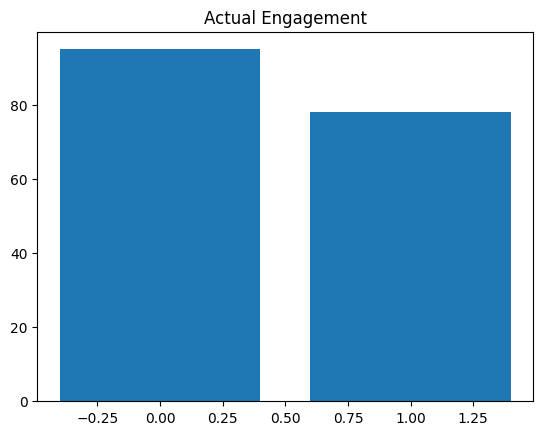

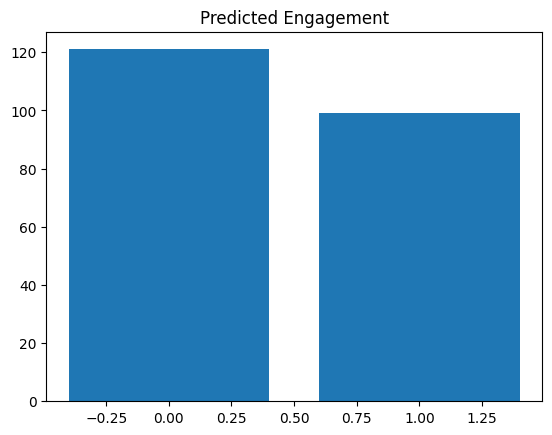

In [11]:
# Plot
plt.figure()
plt.bar(range(len(y_test)), y_test)
plt.title('Actual Engagement')
plt.show()

plt.figure()
plt.bar(range(len(y_pred)), y_pred)
plt.title('Predicted Engagement')
plt.show()